# Vesper — Cap-Binding Diagnostics

For each ticker that the optimizer pinned at the ±3% per-name gross cap,
overlay three time series to spot *which signal* the optimizer was reacting to:

1. **Weekly PnL contribution** — `weight × realised raw_ret` for that week.
2. **NLP information-decay score** — TF-IDF cosine to prior quarter, 0-1.
3. **Graph shock score** — row-normalised supply-chain diffusion, 0-1.

This is the diagnostic counterpart to ``notebooks/evaluation.ipynb``'s
cap-binding histogram: that notebook tells you *who* is pinned; this
notebook tells you *why*.

Run from the repository root:

```bash
jupyter notebook notebooks/cap_binding_diagnostics.ipynb
```

Or headless:

```bash
jupyter nbconvert --to notebook --execute notebooks/cap_binding_diagnostics.ipynb \
    --output cap_binding_diagnostics.ipynb
```


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

matplotlib.use("Agg")  # headless-safe; overridden by %matplotlib inline below
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
_candidate = NOTEBOOK_DIR if (NOTEBOOK_DIR / "main.py").exists() else NOTEBOOK_DIR.parent
if not (_candidate / "main.py").exists():
    for _parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
        if (_parent / "main.py").exists():
            _candidate = _parent
            break
REPO_ROOT = _candidate
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from vesper.main import run_backtest  # noqa: E402

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_DIR = REPO_ROOT / "data"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"REPO_ROOT={REPO_ROOT}")
print(f"FIG_DIR={FIG_DIR}")


REPO_ROOT=/Users/shrxvxn/Downloads/Vesper
FIG_DIR=/Users/shrxvxn/Downloads/Vesper/data/figures


In [2]:
# Run the backtest end-to-end and pull out the per-(date, ticker) features
# and weights the optimizer actually saw. ``weekly_features`` is exposed
# by ``run_backtest`` precisely so this notebook can correlate signals
# with weights / PnL without re-running the pipeline.
result = run_backtest(data_dir=str(DATA_DIR))
weights = result.weights.copy()
features = result.weekly_features.copy() if result.weekly_features is not None else None

if features is None:
    raise RuntimeError(
        "run_backtest did not return weekly_features. "
        "Make sure you are on the latest main branch."
    )

# Realised raw returns per (date, ticker). We need raw_ret to compute
# per-name PnL contribution = weight * raw_ret. Pulled directly from the
# synthetic market panel; for live EDGAR runs this would be sourced from
# the same place.
weekly = pd.read_parquet(DATA_DIR / "weekly_returns.parquet")
raw_ret = weekly.set_index(["date", "ticker"])[["raw_ret"]]

print(f"weights:  {weights.shape} ({weights.index.get_level_values(1).nunique()} tickers, "
      f"{weights.index.get_level_values(0).nunique()} weeks)")
print(f"features: {features.shape}")
print(f"raw_ret:  {raw_ret.shape}")


2026-07-16 17:02:28 [vesper.main] INFO: Loading synthetic artefacts from /Users/shrxvxn/Downloads/Vesper/data


2026-07-16 17:02:29 [vesper.main] INFO: Backtest complete: {'n_periods': 101, 'n_tradeable_tickers': 12, 'avg_weekly_net_pnl': -3e-06, 'total_net_pnl': -0.000327, 'realised_turnover_weekly': 0.005374, 'max_gross_weight': 0.030002, 'dollar_neutrality_violation': 0.0}


weights:  (1212, 1) (12 tickers, 101 weeks)
features: (1212, 5)
raw_ret:  (1212, 1)


## 1. Identify cap-binding tickers

We pin a ticker as **cap-binding** if its maximum gross weight over the
backtest comes within 0.5% of the ±3% cap (i.e., `max |w| ≥ 0.0295`). This
excludes names that flirted with but never quite hit the cap.


In [3]:
CAP = 0.03
CAP_BINDING_THRESHOLD = 0.0295  # 0.5% slack

per_ticker_max_abs = weights["weight"].abs().groupby(level="ticker").max()
cap_binding_tickers = sorted(
    per_ticker_max_abs[per_ticker_max_abs >= CAP_BINDING_THRESHOLD]
    .sort_values(ascending=False)
    .index.tolist()
)
print(f"Cap-binding tickers (max |w| >= {CAP_BINDING_THRESHOLD}): "
      f"{len(cap_binding_tickers)} / {weights.index.get_level_values(1).nunique()}")
for t in cap_binding_tickers:
    print(f"  {t}: max |w| = {per_ticker_max_abs[t]:.4f}")

# Build a single tidy long-form frame: one row per (date, ticker) for
# cap-binding tickers only, with PnL contribution + both signals.
# NOTE: ``features`` already carries a ``raw_ret`` column (from the market
# panel that was joined in run_backtest). To avoid a pandas column-name
# collision when we later merge the parquet-derived ``raw_ret_long`` we
# select only the signal columns from ``features`` here.
weights_long = weights.reset_index()
features_long = features.reset_index()[["date", "ticker", "nlp_decay_score", "graph_shock_score"]]
raw_ret_long = raw_ret.reset_index()

merged = (
    weights_long
    .merge(features_long, on=["date", "ticker"], how="left")
    .merge(raw_ret_long, on=["date", "ticker"], how="left")
)
merged["pnl_contribution"] = merged["weight"] * merged["raw_ret"]

cap_long = (
    merged[merged["ticker"].isin(cap_binding_tickers)]
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)
print(f"\ncap_long shape: {cap_long.shape}")
print(cap_long.head(3).to_string())


Cap-binding tickers (max |w| >= 0.0295): 8 / 12
  ADBE: max |w| = 0.0300
  AVGO: max |w| = 0.0300
  CRM: max |w| = 0.0300
  GOOGL: max |w| = 0.0300
  INTC: max |w| = 0.0300
  MSFT: max |w| = 0.0300
  NVDA: max |w| = 0.0300
  ORCL: max |w| = 0.0300

cap_long shape: (808, 7)
        date ticker        weight  nlp_decay_score  graph_shock_score   raw_ret  pnl_contribution
0 2022-09-09   ADBE -1.060843e-13              0.0                0.0 -0.000839      8.895756e-17
1 2022-09-16   ADBE -2.115387e-13              0.0                0.0  0.020082     -4.248134e-15
2 2022-09-23   ADBE -3.168537e-13              0.0                0.0  0.005013     -1.588339e-15


## 2. Per-ticker overlay plots

One row per cap-binding ticker, three columns:
- **Col 1**: weekly PnL contribution (weight × raw_ret).
- **Col 2**: NLP information-decay score in [0, 1].
- **Col 3**: graph shock score in [0, 1].

Red horizontal dashed line at the +3% cap (only meaningful in col 2/3
visually if you overlay weight; here it acts as a visual reminder).
We *highlight* weeks where |weight| ≥ 0.0295 with a faint red band so the
optimizer's pinning behavior is visible against the signal time series.


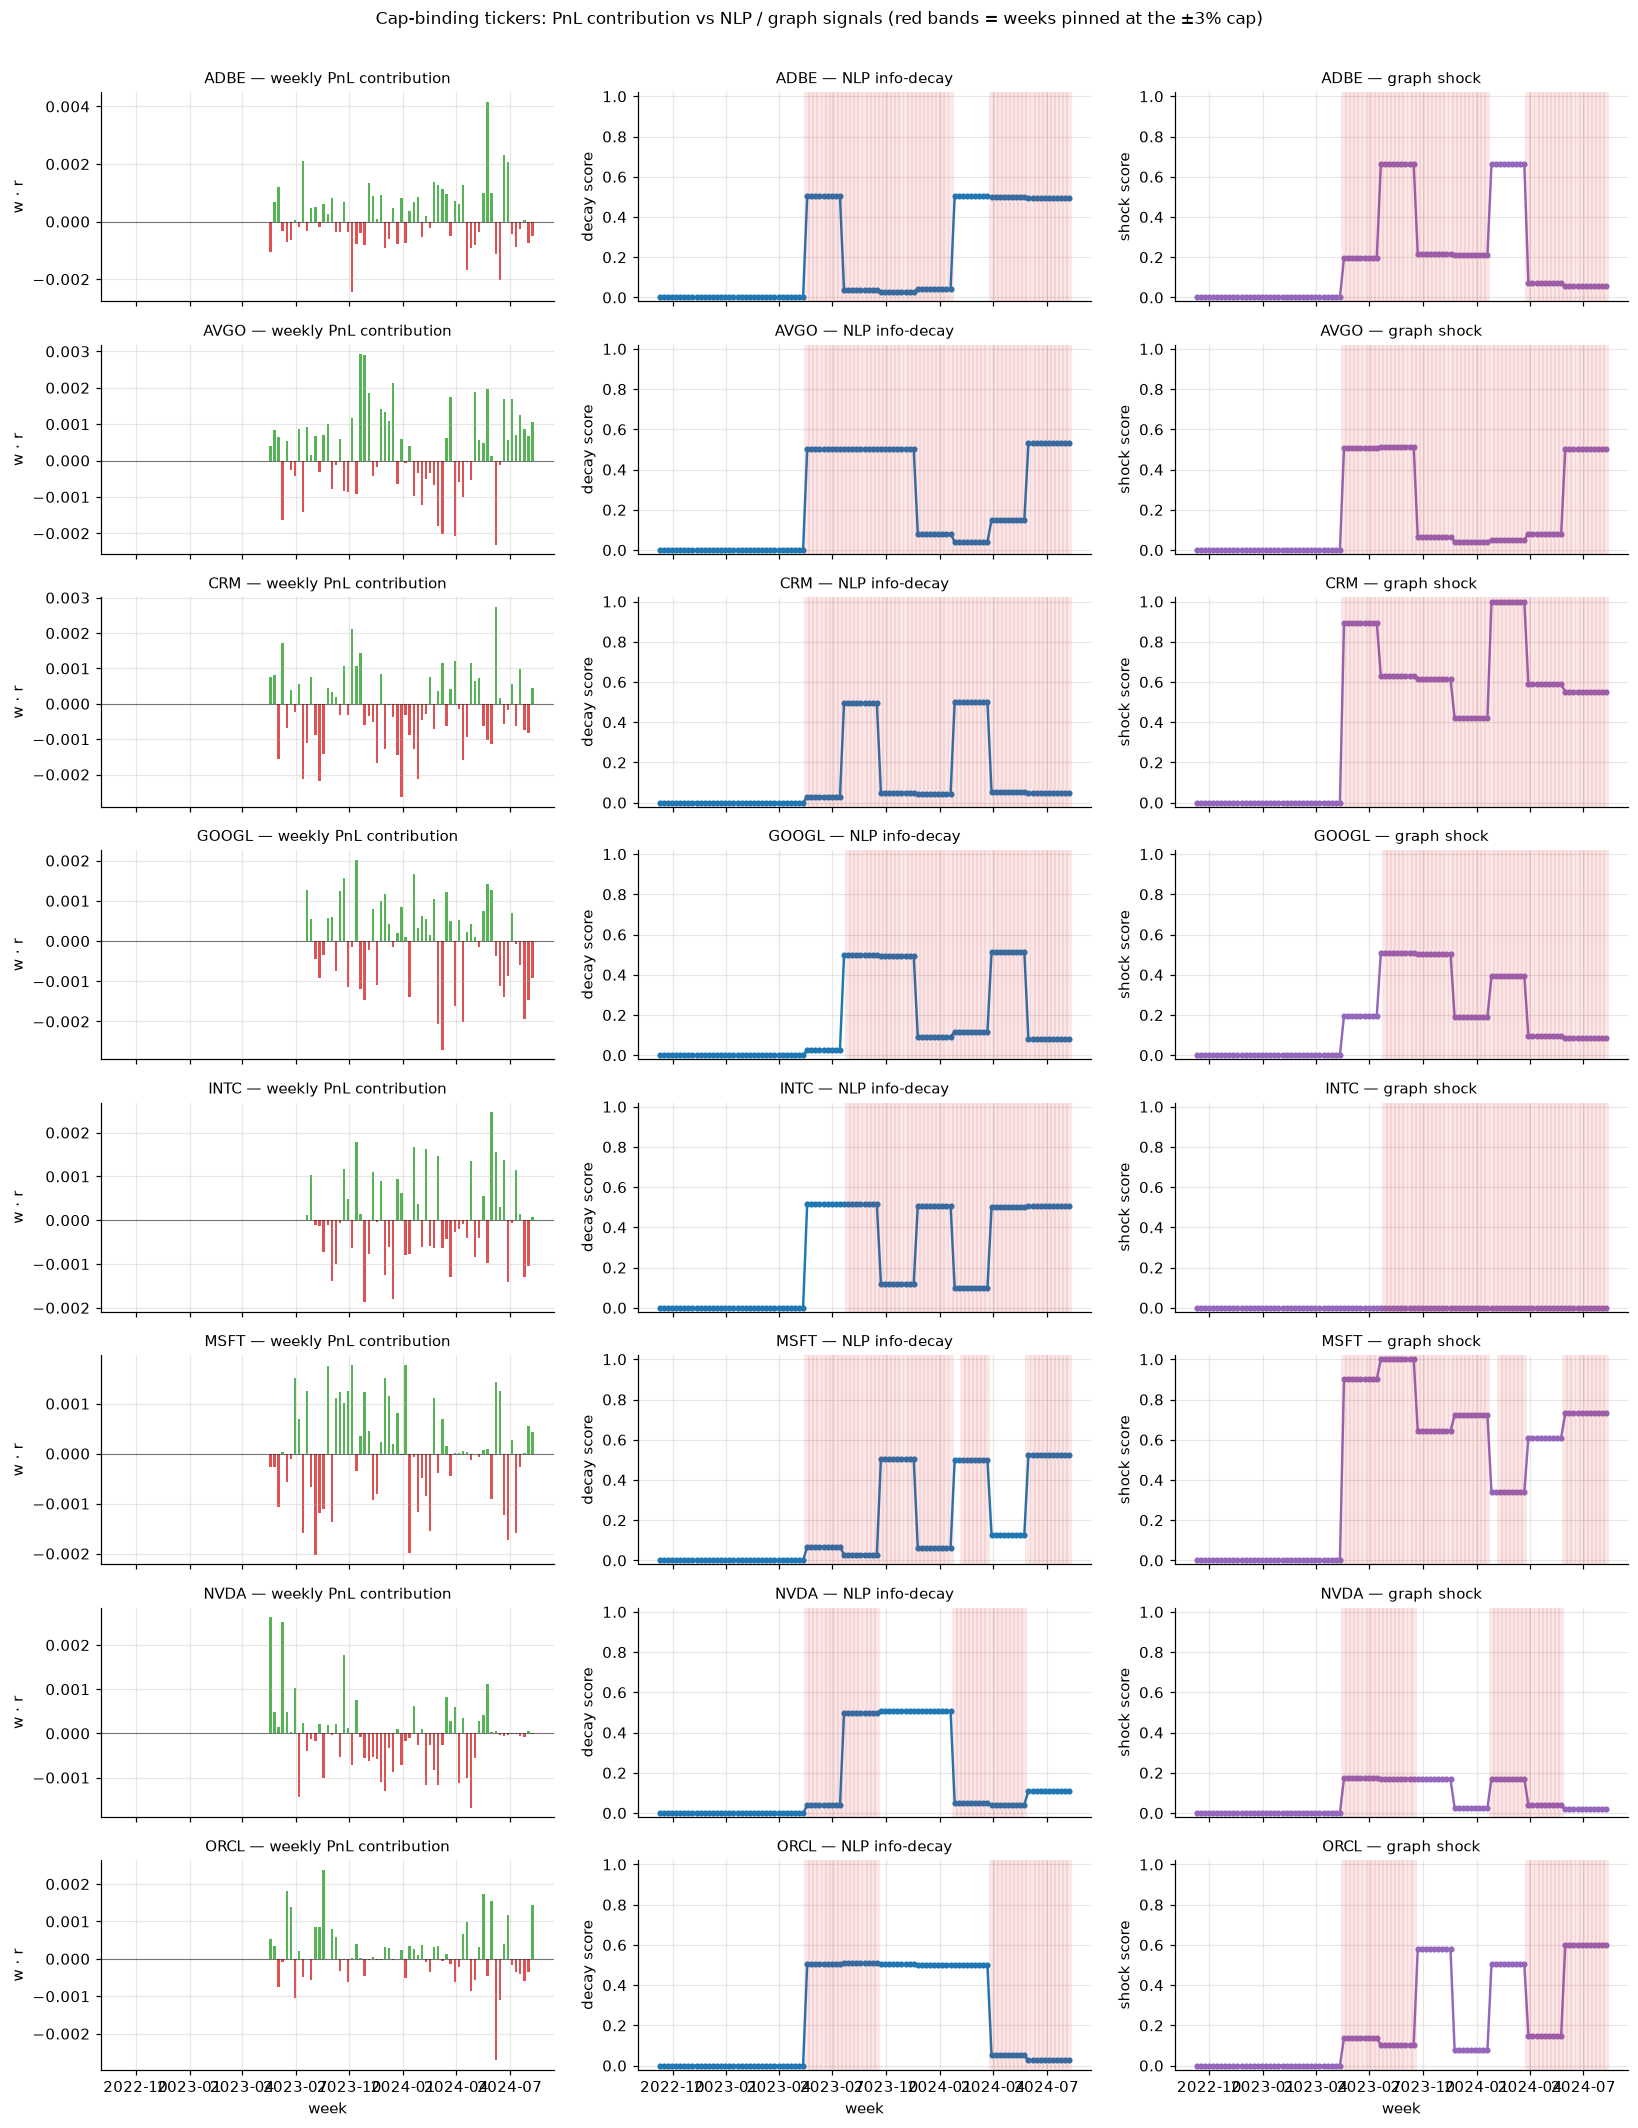

Saved /Users/shrxvxn/Downloads/Vesper/data/figures/cap_binding_diagnostics.png


In [4]:
N = len(cap_binding_tickers)
if N == 0:
    print("No cap-binding tickers in this run; nothing to plot.")
else:
    fig, axes = plt.subplots(N, 3, figsize=(15, 2.4 * N), sharex=True)
    if N == 1:
        axes = np.array([axes])  # ensure 2-D indexing

    for row, ticker in enumerate(cap_binding_tickers):
        sub = cap_long[cap_long["ticker"] == ticker].copy()

        # Identify cap-pinned weeks (|w| >= 0.0295) for shading.
        pinned = sub["weight"].abs() >= CAP_BINDING_THRESHOLD
        pin_dates = sub.loc[pinned, "date"]

        # Col 1: PnL contribution
        ax = axes[row, 0]
        colors = np.where(sub["pnl_contribution"] >= 0, "tab:green", "tab:red")
        ax.bar(sub["date"], sub["pnl_contribution"], color=colors, width=4.0, alpha=0.8)
        ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
        ax.set_title(f"{ticker} — weekly PnL contribution", fontsize=10)
        ax.set_ylabel("w \u00b7 r")
        if row == N - 1:
            ax.set_xlabel("week")

        # Col 2: NLP decay
        ax = axes[row, 1]
        ax.plot(sub["date"], sub["nlp_decay_score"], color="tab:blue",
                linewidth=1.6, marker="o", markersize=3)
        for d in pin_dates:
            ax.axvline(d, color="tab:red", alpha=0.10, linewidth=4.0)
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(f"{ticker} — NLP info-decay", fontsize=10)
        ax.set_ylabel("decay score")
        if row == N - 1:
            ax.set_xlabel("week")

        # Col 3: Graph shock
        ax = axes[row, 2]
        ax.plot(sub["date"], sub["graph_shock_score"], color="tab:purple",
                linewidth=1.6, marker="o", markersize=3)
        for d in pin_dates:
            ax.axvline(d, color="tab:red", alpha=0.10, linewidth=4.0)
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(f"{ticker} — graph shock", fontsize=10)
        ax.set_ylabel("shock score")
        if row == N - 1:
            ax.set_xlabel("week")

    fig.suptitle(
        "Cap-binding tickers: PnL contribution vs NLP / graph signals "
        "(red bands = weeks pinned at the \u00b13% cap)",
        fontsize=11, y=1.005,
    )
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cap_binding_diagnostics.png",
                bbox_inches="tight", dpi=120)
    plt.show()
    print(f"Saved {FIG_DIR / 'cap_binding_diagnostics.png'}")


## 3. Summary table — which signal moves with the pin?

For each cap-binding ticker, report:
- Mean |weight|, max |weight|, weeks pinned.
- Pearson correlation between |weight| and each signal, lagged by 0/+1 weeks.
- Total and mean PnL contribution.


In [5]:
summary_rows = []
for ticker in cap_binding_tickers:
    sub = cap_long[cap_long["ticker"] == ticker].sort_values("date").copy()
    if len(sub) < 5:
        # Correlation is meaningless with too few samples.
        continue
    abs_w = sub["weight"].abs()
    nlp = sub["nlp_decay_score"]
    shock = sub["graph_shock_score"]
    # Lag the signals by +1 week to see if *next-week* signal predicts pinning.
    nlp_lag1 = nlp.shift(-1)
    shock_lag1 = shock.shift(-1)
    row = {
        "ticker": ticker,
        "weeks": len(sub),
        "weeks_pinned": int((abs_w >= CAP_BINDING_THRESHOLD).sum()),
        "mean_abs_w": float(abs_w.mean()),
        "max_abs_w": float(abs_w.max()),
        "total_pnl": float(sub["pnl_contribution"].sum()),
        "mean_pnl": float(sub["pnl_contribution"].mean()),
        "corr_absw_nlp_t":      float(abs_w.corr(nlp)),
        "corr_absw_shock_t":    float(abs_w.corr(shock)),
        "corr_absw_nlp_t+1":    float(abs_w.corr(nlp_lag1)),
        "corr_absw_shock_t+1":  float(abs_w.corr(shock_lag1)),
    }
    summary_rows.append(row)

if summary_rows:
    summary_df = pd.DataFrame(summary_rows).set_index("ticker")
    # Highlight which signal correlates more strongly with |weight| for each
    # ticker; that is our best guess at *why* the optimizer pinned it.
    summary_df["dominant_signal_t"] = np.where(
        summary_df["corr_absw_nlp_t"].abs() > summary_df["corr_absw_shock_t"].abs(),
        "NLP", "Shock",
    )
    summary_df["dominant_signal_t+1"] = np.where(
        summary_df["corr_absw_nlp_t+1"].abs() > summary_df["corr_absw_shock_t+1"].abs(),
        "NLP", "Shock",
    )
    pd.set_option("display.float_format", lambda v: f"{v:+.3f}")
    print(summary_df.to_string())
else:
    print("No cap-binding tickers; nothing to summarise.")


        weeks  weeks_pinned  mean_abs_w  max_abs_w  total_pnl  mean_pnl  corr_absw_nlp_t  corr_absw_shock_t  corr_absw_nlp_t+1  corr_absw_shock_t+1 dominant_signal_t dominant_signal_t+1
ticker                                                                                                                                                                                   
ADBE      101            56      +0.019     +0.030     +0.009    +0.000           +0.573             +0.494             +0.538               +0.502               NLP                 NLP
AVGO      101            65      +0.019     +0.030     +0.016    +0.000           +0.692             +0.571             +0.659               +0.532               NLP                 NLP
CRM       101            65      +0.019     +0.030     -0.011    -0.000           +0.447             +0.906             +0.450               +0.872             Shock               Shock
GOOGL     101            55      +0.017     +0.030     -0.003    -0.00

/Users/shrxvxn/Library/Python/3.13/lib/python/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/shrxvxn/Library/Python/3.13/lib/python/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [6]:
print("\nDiagnostics:")
print(f"  cap-binding tickers identified: {len(cap_binding_tickers)}")
print(f"  figures saved to: {FIG_DIR}/")



Diagnostics:
  cap-binding tickers identified: 8
  figures saved to: /Users/shrxvxn/Downloads/Vesper/data/figures/
